# Emotional Receipts — Explainer Notebook
### *A nation's playlist as its therapy bill — guess who's happier?*

**02806 Social Data Analysis & Visualization** · DTU · Spring 2026  
**Companion website:** [`./index.html`](./index.html)  
**Dataset:** Spotify Daily Charts (Kaggle) joined to the World Happiness Report 2019.  

---



## 1 · Motivation

### 1.1 What is the dataset?

We use **two** datasets, joined at the country level.

**Primary — Spotify Daily Top-200 (2017–2020).** A Kaggle release of Spotify's national daily Top-200 charts across 35 regions (34 countries + a *Global* aggregate). After cleaning, 170,614 chart entries, 21 audio-feature columns per track. For each track, Spotify's audio extractor [[1](#ref1)] provides bounded `[0, 1]` scores for valence, energy, danceability, acousticness, speechiness, instrumentalness, liveness, loudness, tempo and others. We use **ten** of these features.

**Secondary — World Happiness Report 2019.** The standard cross-national wellbeing measurement, derived from the Gallup World Poll. We use the **ladder score** (Cantril ladder, 0–10 scale) for 156 countries; 34 of those overlap with our Spotify country set.

The Spotify *Global* row is kept as an explicit baseline rather than dropped, but excluded from any test that requires a WHR score.

### 1.2 Why this dataset?

The two pivotal reasons behind the opting of Spotify charts data as the audio side and WHR as the wellbeing side:

**(a) Streaming is revealed preference.** Surveys ask people what they like; Spotify records what they actually press play on. There is no social-desirability bias in a chart position. If a country streams melancholy at scale, it really is streaming melancholy.

**(b) Spotify's audio extractor is uniform across countries and languages.** Every track on the platform is run through the same model, so cross-country comparison doesn't suffer the translation drift that survey instruments do. A valence score for a Korean track and a Colombian track are computed by the same pipeline.

On the WHR side: it's the only widely-trusted, globally-comparable, methodologically-stable measurement of national wellbeing that's well documented. [[2](#ref2)].

### 1.3 Goal for the end-user experience

A person with no background in Song Features, WHR or Segel-Heer should leave the website with two things:

**(i) The metric in one sentence.** They should be able to define the *coping ratio* (energy ÷ (valence + 0.01)) and explain why a value of 1.0 is a meaningful anchor — without scrolling back.

**(ii) The verdict.** They should remember **which** features actually correlate with national happiness — **acousticness** negatively, **speechiness** positively, **valence** and **energy** essentially flat — even if they forget the exact r-values. The directional shape (positive or negative) is what should stick.

### 1.4 Working hypothesis

The hypothesis we set out to test:

> *The proportion of valence- and energy-rated songs in a country's chart reflects emotional coping patterns and offers an alternative perspective on national well-being.*

Operationalised: high-valence, high-energy charts should correlate **positively** with WHR; low-valence, low-energy charts should correlate **negatively**.

### Setup


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy import stats as sps

# Cyber-noir palette — matches the website exactly.
BG, FG  = '#05050a', '#e6e6f0'
CYAN    = '#00e5ff'
MAGENTA = '#ff2ec4'
AMBER   = '#ffb400'

mpl.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': BG, 'savefig.facecolor': BG,
    'axes.edgecolor': '#3a3a4f', 'axes.labelcolor': FG,
    'xtick.color': FG, 'ytick.color': FG, 'text.color': FG,
    'font.family': 'sans-serif',
    'font.size': 11, 'axes.titlesize': 14, 'axes.titleweight': 'bold',
    'axes.spines.top': False, 'axes.spines.right': False,
})

## 2 · Basic stats

### 2.1 Cleaning and preprocessing — the choices we made

- **Kept all 170,614 rows.** No outlier removing. The audio features are bounded `[0, 1]` and the tails are *informative* — a track with valence 0.05 isn't a glitch, it's a moody one. Trimming would systematically bias toward the centre of the audio space.

- **Kept the Spotify *Global* row.** It serves as an explicit baseline (the global mean coping ratio = 1.30) that several charts reference.

- **Country aggregation = unweighted mean across chart appearances.** A track that recurs many times in a country's chart contributes proportionally more to that country's mean. This implicitly weights by *listening exposure*, which is closer to what the metaphor of "a country's playlist" actually means than a deduplicated track list would be.

- **WHR matched on 34 of 35 regions.** *Global* has no WHR equivalent. We use a single year (2019) rather than averaging across years — see Section 6.1 (Discussion) for the full justification.

- **Continents assigned manually** in three buckets: Europe (17 countries), Americas (10), Asia/Oceania (7) for dropdown view to be meaningful, small enough that an entire group renders on screen at once.

- **No imputation.** Every audio feature in the Kaggle release was complete on every row we kept; nothing needed to be filled in.


In [2]:
df = pd.read_csv('final_spotify_dataset.csv')
print(f'Shape: {df.shape}, Unique Tracks: {df.Uri.nunique()}, regions: {df.Country.nunique()}')

Shape: (170614, 21), Unique Tracks: 62416, regions: 35


### 2.2 Distributions of the Audio Features

Before any country-level aggregation, we look at the raw distributions across all 170,614 tracks.


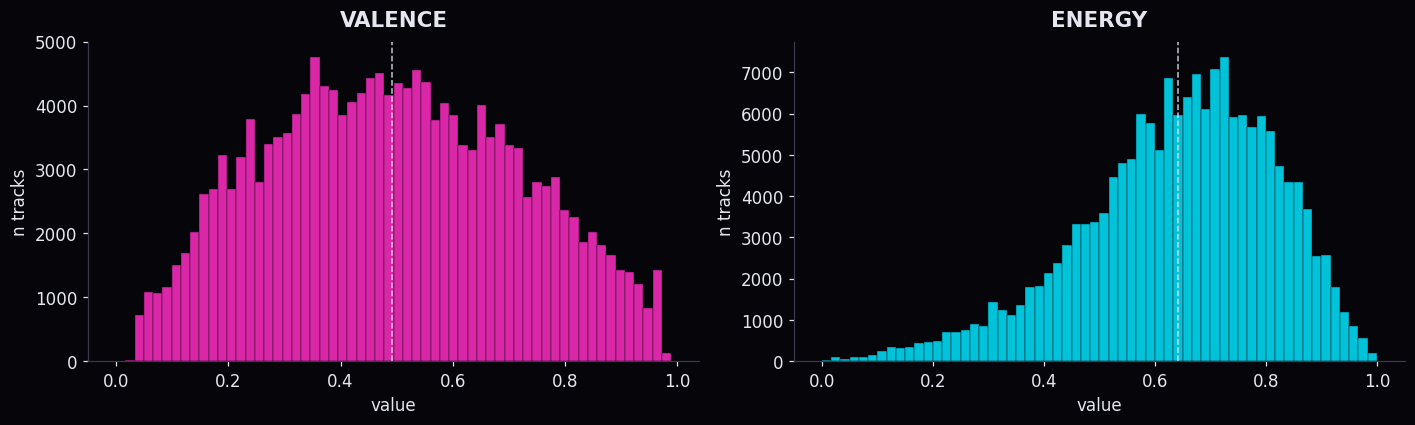

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), dpi=110)
for ax, col, color in zip(axes, ['valence', 'energy'],
                          [MAGENTA, CYAN]):
    ax.hist(df[col], bins=60, color=color, alpha=0.85, edgecolor=BG, linewidth=0.3)
    ax.axvline(df[col].mean(), color=FG, linestyle='--', linewidth=1, alpha=0.85)
    ax.set_title(col.upper(), color=FG, pad=10)
    ax.set_xlabel('value'); ax.set_ylabel('n tracks')
plt.tight_layout()
plt.show()

*Figure 1 · Distributions of the two audio features across all 170,614 tracks including the mean line. The global mean valence is ≈ 0.48. Energy peaks around 0.65.*

Two observations matter for what follows. First, **valence on the global Top-200 is mildly *negatively* skewed** — even before we look at any happiness data, the world's most-streamed tracks aren't unambiguously cheerful. Second, **the distributions are well-behaved across the full `[0, 1]` range**, with no degenerate spikes at 0 or 1. Both reassure us that taking country-level *means* of these features will produce stable, comparable numbers.

### 2.3 Country-level audio space

Aggregating to the country level: each country becomes one point in feature-space, defined by the unweighted mean of every audio feature across its chart appearances. We then map a continent and look up the WHR 2019 ladder score.


In [4]:
FEATS = ['valence','energy','danceability','acoustics','loudness','tempo',
         'speechiness','instrumentalness','liveliness','mode']

cf = df.groupby('Country')[FEATS].mean()
cf['n_tracks'] = df.groupby('Country').size()
cf['coping_ratio'] = cf['energy'] / (cf['valence'] + 0.01)
global_ratio = float(cf.loc['Global','coping_ratio'])

WHR_2019 = {
    'Finland':7.769,'Denmark':7.600,'Norway':7.554,'Netherlands':7.488,
    'Switzerland':7.480,'Sweden':7.343,'New Zealand':7.307,'Canada':7.278,
    'Austria':7.246,'Australia':7.228,'Costa Rica':7.167,'UK':7.054,
    'Ireland':7.021,'Germany':6.985,'Belgium':6.923,'USA':6.892,
    'Mexico':6.595,'France':6.592,'Taiwan':6.446,'Chile':6.444,
    'Spain':6.354,'Brazil':6.300,'Singapore':6.262,'Italy':6.223,
    'Poland':6.182,'Colombia':6.125,'Argentina':6.086,'Ecuador':6.028,
    'Peru':5.697,'Portugal':5.693,'Philippines':5.631,'Turkey':5.373,
    'Malaysia':5.339,'Indonesia':5.192}

CONTINENTS = {
    'Europe':['Austria','Belgium','Denmark','Finland','France','Germany',
             'Ireland','Italy','Netherlands','Norway','Poland','Portugal',
             'Spain','Sweden','Switzerland','Turkey','UK'],
    'Americas':['Argentina','Brazil','Canada','Chile','Colombia','Costa Rica',
               'Ecuador','Mexico','Peru','USA'],
    'Asia/Oceania':['Australia','Indonesia','Malaysia','New Zealand',
                   'Philippines','Singapore','Taiwan']}
cont_map = {c:k for k,v in CONTINENTS.items() for c in v}

cfr = cf.reset_index()
cfr['whr']       = cfr['Country'].map(WHR_2019)
cfr['continent'] = cfr['Country'].map(cont_map)
cfc = cfr[cfr.Country != 'Global'].dropna(subset=['whr']).copy()
cfc['whr_rank'] = cfc['whr'].rank(ascending=False, method='min').astype(int)
print(f'Global baseline coping ratio: {global_ratio:.3f}')
cfc[['Country','valence','energy','coping_ratio','whr','continent']].head()

Global baseline coping ratio: 1.295


,Country,valence,energy,coping_ratio,whr,continent
0,Argentina,0.578100,0.680882,1.157766,6.086,Americas
1,Australia,0.471691,0.631896,1.311829,7.228,Asia/Oceania
2,Austria,0.474881,0.655426,1.351726,7.246,Europe
3,Belgium,0.481517,0.633013,1.287876,6.923,Europe
4,Brazil,0.561978,0.676303,1.182394,6.300,Americas


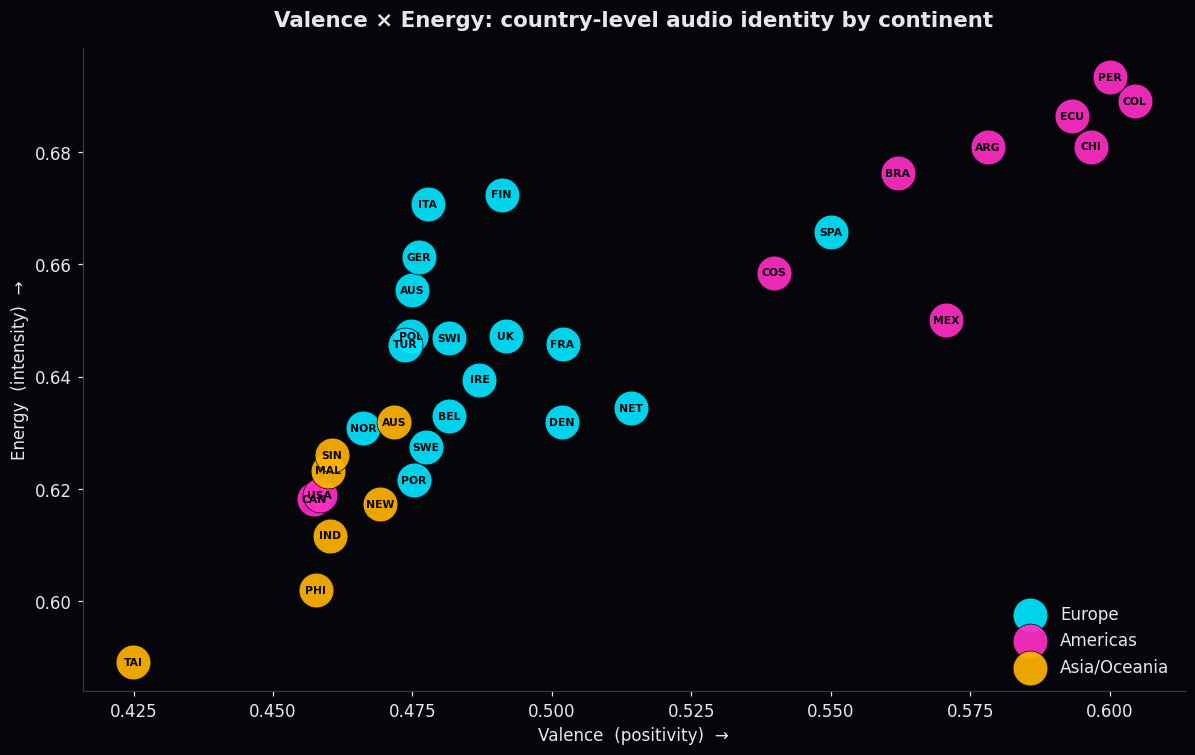

In [5]:
fig, ax = plt.subplots(figsize=(11, 7), dpi=110)
for cont, color in [('Europe', CYAN), ('Americas', MAGENTA), ('Asia/Oceania', AMBER)]:
    sub = cfc[cfc['continent'] == cont]
    ax.scatter(sub['valence'], sub['energy'], s=520, c=color, label=cont,
               alpha=0.92, edgecolor=BG, linewidth=0.5)
    for _, r in sub.iterrows():
        ax.text(r['valence'], r['energy'], r['Country'][:3].upper(),
                fontsize=7, color=BG, va='center', ha='center', weight='bold')
ax.set_xlabel('Valence  (positivity)  →')
ax.set_ylabel('Energy  (intensity)  →')
ax.set_title('Valence × Energy: country-level audio identity by continent', pad=14, color=FG)
ax.legend(loc='lower right', facecolor=BG, edgecolor='none', labelcolor=FG)
plt.tight_layout()
plt.show()

*Figure 2 · Each dot is one country's mean position in valence × energy space.*

- **Latin-American nations cluster upper-right** — high positivity, high energy, the cultural cliché of celebration music. 
- **European nations cluster around the center** — comparable energy, markedly lower positivity. 
- **Asia/Oceania splits** between the two regions, with Taiwan an outlier at the very bottom-left.

This is the cultural wallpaper against which the rest of the analysis happens. Note already: Finland, the world's happiest country in WHR 2019, sits firmly inside the European cluster.

## 3 · Data Analysis

### 3.1 Defining the metric: the coping ratio

From the distributions of Audio Features, we can already see that the world's most-streamed music isn't unambiguously cheerful. To compress that observation into one country-level number, we define:

$$\text{coping\_ratio}_c \;=\; \frac{\overline{\text{energy}}_c}{\overline{\text{valence}}_c \;+\; 0.01}$$

**Why a ratio?** A ratio follows a natural anchor: 1.0 = energy and positivity in balance. Above 1 = energy outpaces positivity; below 1 = positivity outpaces energy. Because both valence and energy live on `[0, 1]`, the ratio inherits this bounded, interpretable scale.

The coping ratio captures how much energy a country's chart carries *relative to* how positive it sounds. A higher ratio means the music is reaching for something the brightness isn't matching. Listeners use music for *mood regulation* — not just for expressing how they feel, but for actively shaping it — and the coping ratio operationalises that idea at the population level: a country's chart records what its listeners *reach for*.


In [6]:
print('Top 5 by coping ratio:\n')
print(cfc.nlargest(5, 'coping_ratio')[['Country','coping_ratio','whr','whr_rank']].to_string())
print('\n\nBottom 5 by coping ratio:\n')
print(cfc.nsmallest(5, 'coping_ratio')[['Country','coping_ratio','whr','whr_rank']].to_string())

Top 5 by coping ratio:

    Country  coping_ratio    whr  whr_rank
17    Italy      1.375190  6.223        24
13  Germany      1.360365  6.985        14
31   Taiwan      1.354735  6.446        19
2   Austria      1.351726  7.246         9
11  Finland      1.342205  7.769         1


Bottom 5 by coping ratio:

     Country  coping_ratio    whr  whr_rank
19    Mexico      1.119601  6.595        17
7   Colombia      1.121424  6.125        26
6      Chile      1.122477  6.444        20
23      Peru      1.136645  5.697        29
10   Ecuador      1.138071  6.028        28


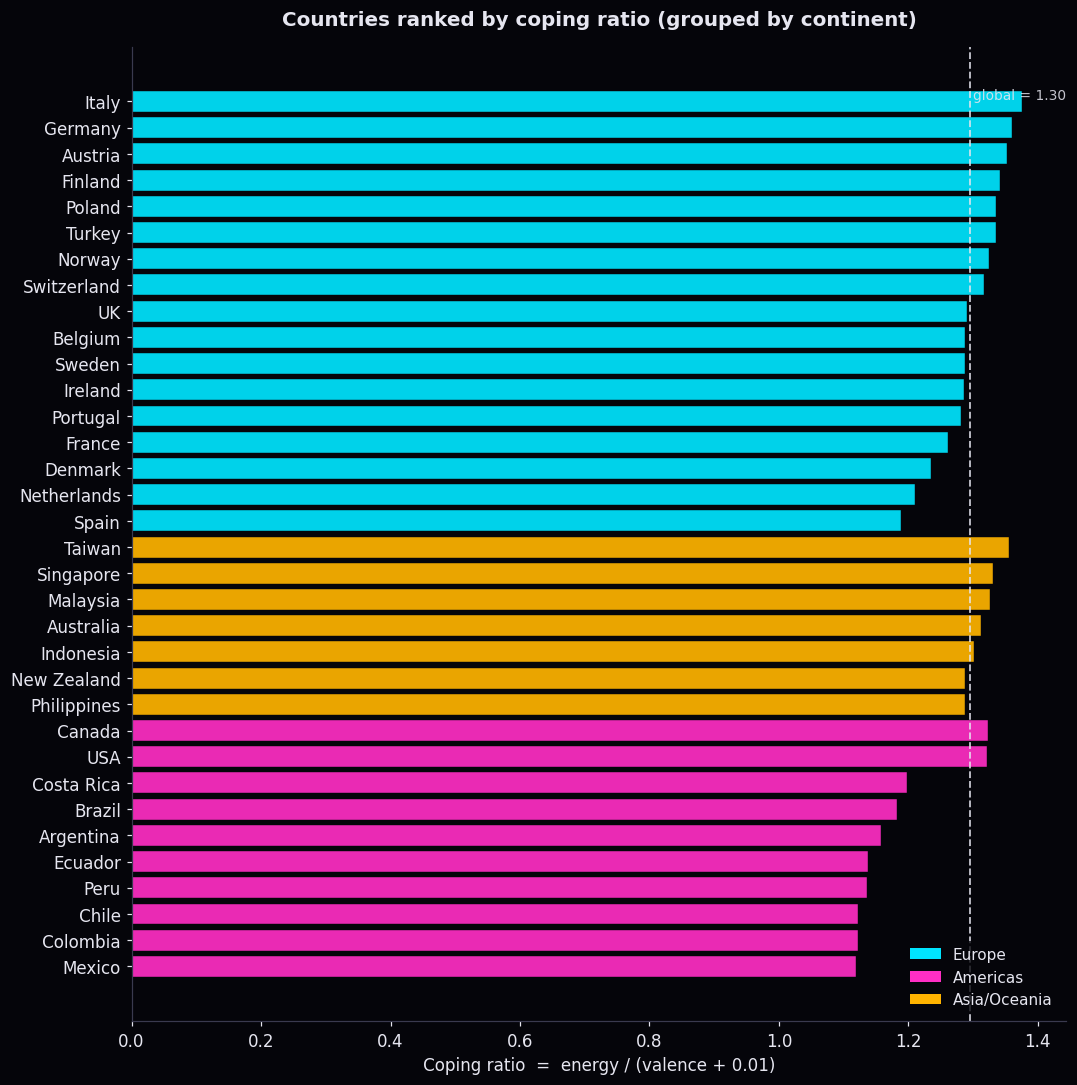

In [7]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=110)
cfs = cfc.sort_values(['continent', 'coping_ratio'])
bar_colors_map = {'Europe': CYAN, 'Americas': MAGENTA, 'Asia/Oceania': AMBER}
bar_colors = [bar_colors_map[c] for c in cfs['continent']]
y_pos = np.arange(len(cfs))
ax.barh(y_pos, cfs['coping_ratio'], color=bar_colors, alpha=0.92,
        edgecolor=BG, linewidth=0.3)
ax.set_yticks(y_pos); ax.set_yticklabels(cfs['Country'])
ax.axvline(global_ratio, color=FG, linestyle='--', linewidth=1.2, alpha=0.85)
ax.text(global_ratio + 0.005, len(cfs) - 0.5,
        f'global = {global_ratio:.2f}', fontsize=9, color=FG, alpha=0.85, ha='left', va='top')
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=CYAN, label='Europe'),
                  Patch(facecolor=MAGENTA, label='Americas'),
                  Patch(facecolor=AMBER, label='Asia/Oceania')]
ax.legend(handles=legend_handles, loc='lower right',
          facecolor=BG, edgecolor='none', labelcolor=FG, fontsize=10)
ax.set_xlabel('Coping ratio  =  energy / (valence + 0.01)')
ax.set_title('Countries ranked by coping ratio (grouped by continent)',
             pad=14, fontsize=13, color=FG)
plt.tight_layout()
plt.show()

*Figure 3 · Countries ranked by coping ratio, grouped and coloured by continent. The dashed vertical line represents the global baseline (≈ 1.30).*

The grouping makes the cultural split immediately visible: **the Americas sit almost entirely below the global baseline**, while Europe and Asia/Oceania sit almost entirely above it. Within Europe, only Spain, Netherlands, Denmark, France and Portugal dip below — the rest run hot.

### 3.2 Pearson correlations vs WHR

With one happiness number per country and 10 audio features per country, the simplest test of the hypothesis is a Pearson correlation between each feature and WHR.

**Why Pearson.** Our initial hypothesis is *linear* — happier countries listen to more positive music, in proportion. Pearson tests precisely that: a linear relationship between two continuous variables. We use `scipy.stats.pearsonr`, which returns the correlation coefficient `r` and the two-sided p-value (testing the null that `r = 0`). 

**Why against WHR.** WHR is the only widely-trusted, country-level wellbeing measurement we have. With only 34 countries, pairing each audio feature with this single anchor gives us 10 interpretable test results — much cleaner than a 10 × 10 inter-feature matrix where the reader would have to find the WHR column and ignore the rest.


In [8]:
print('Feature            r                p')
print('-' * 50)
corr_rows = []
for col in ['valence', 'energy', 'danceability', 'acoustics', 'loudness',
              'tempo', 'speechiness', 'instrumentalness', 'liveliness', 'mode']:
    r, p = sps.pearsonr(cfc[col], cfc['whr'])
    corr_rows.append({'feat': col, 'r': r, 'p': p})
    sig = '  *' if p < 0.05 else ''
    print(f'{col:14s}   r = {r:+.3f}   p = {p:.4f}{sig}')
cdf = pd.DataFrame(corr_rows).sort_values('r')

Feature            r                p
--------------------------------------------------
valence          r = -0.163   p = 0.3558
energy           r = -0.063   p = 0.7230
danceability     r = +0.170   p = 0.3370
acoustics        r = -0.520   p = 0.0016  *
loudness         r = -0.279   p = 0.1107
tempo            r = -0.150   p = 0.3970
speechiness      r = +0.467   p = 0.0053  *
instrumentalness   r = +0.324   p = 0.0616
liveliness       r = -0.014   p = 0.9382
mode             r = -0.185   p = 0.2961


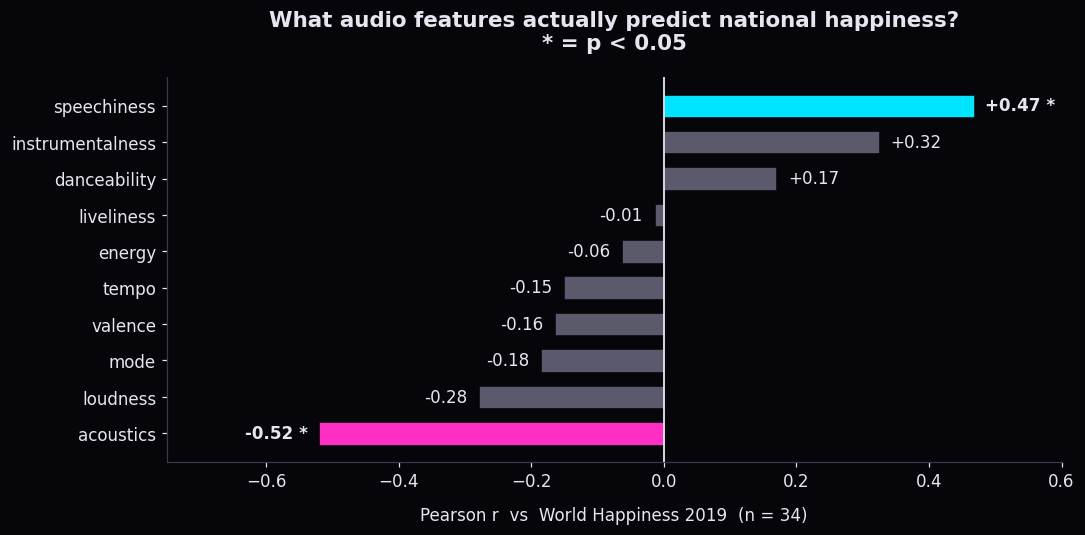

In [9]:
fig, ax = plt.subplots(figsize=(10, 5), dpi=110)
colors = [CYAN if (p < 0.05 and r > 0) else (MAGENTA if p < 0.05 else '#5a5a6c')
          for r, p in zip(cdf['r'], cdf['p'])]
ax.barh(cdf['feat'], cdf['r'], color=colors, height=0.62,edgecolor=BG, linewidth=0.4)
for i, (r, p) in enumerate(zip(cdf['r'], cdf['p'])):
    ax.text(r + (0.018 if r > 0 else -0.018), i,
            f'{r:+.2f}{" *" if p < 0.05 else ""}',
            va='center', ha='left' if r > 0 else 'right',
            fontsize=11, color=FG, weight='bold' if p < 0.05 else 'normal')
ax.axvline(0, color=FG, linewidth=1.2)
ax.set_xlabel('Pearson r  vs  World Happiness 2019  (n = 34)', labelpad=10)
ax.set_title('What audio features actually predict national happiness?\n* = p < 0.05',
             pad=18, fontsize=14)
ax.set_xlim(-0.75, 0.6)
plt.tight_layout()
plt.show()

*Figure 4 · Pearson correlations of ten audio features against WHR 2019 (n = 34).*

- **Acousticness** is the strongest negative predictor (r = −0.520, p = 0.0016).
- **Speechiness** is the strongest positive predictor (r = +0.467, p = 0.0053).
- **Valence** — the feature this project was named after — is essentially flat (r = −0.163, p = 0.356). Coping ratio (r = +0.176) is directionally consistent with the **opposite** of the naive prediction but does not clear conventional significance.
- **Energy** alone is one of the weakest predictors of all ten (r = −0.063, p = 0.723) — almost no relationship between musical intensity and national happiness on its own.
- **Instrumentalness** (r = +0.324, p = 0.0616) is suggestive but doesn't clear conventional significance.
- **Liveliness** is the only feature which is tightly centred on zero (r = −0.014).

**The verdict.** Happier countries do *not* listen to happier-sounding music. They listen to music with **higher speechiness** (rap, spoken-word, narrative-heavy) and **lower acousticness** (more produced, less acoustic-instrument-led). Valence — Spotify's 'happiness' score, the feature this project was originally named after — does not line up with the UN's measurement at all. The initial hypothesis isn't just unsupported; it's pointing in the wrong direction.


### 3.3 The inversion: coping ratio vs happiness

The compositional version of the original hypothesis (`coping_ratio = energy / (valence + 0.01)`) doesn't merely fail to predict happiness — it predicts the *opposite* of what the obvious reading would suggest. The 'loud-cope' countries — high energy relative to their valence — are also the **happiest** countries on average.


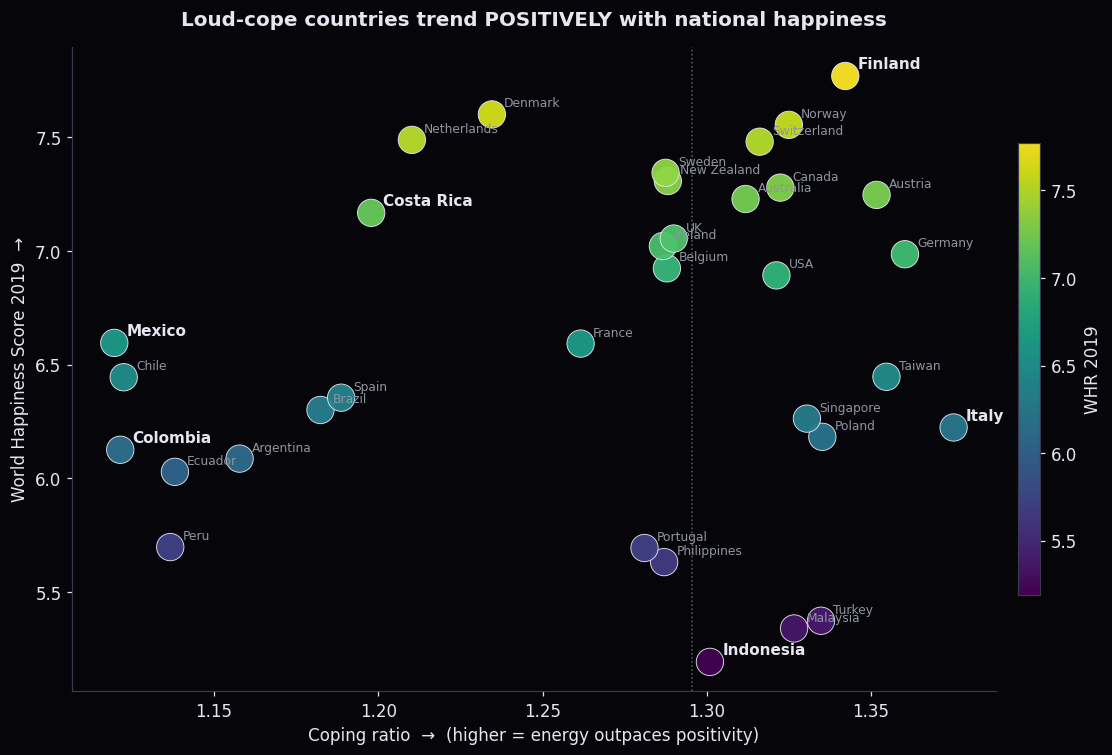

In [10]:
fig, ax = plt.subplots(figsize=(11, 7), dpi=110)
cmap_whr = mpl.colormaps['viridis']
sc = ax.scatter(cfc['coping_ratio'], cfc['whr'], s=320, c=cfc['whr'],
                cmap=cmap_whr, edgecolor=FG, linewidth=0.6, alpha=0.95, zorder=3)
anchors = ('Finland', 'Italy', 'Colombia', 'Mexico', 'Indonesia', 'Costa Rica')
for _, row in cfc.iterrows():
    is_anchor = row['Country'] in anchors
    ax.annotate(row['Country'], (row['coping_ratio'], row['whr']),
                xytext=(8, 5), textcoords='offset points',
                fontsize=10 if is_anchor else 8,
                weight='bold' if is_anchor else 'normal',
                color=FG if is_anchor else '#9095a0')
ax.axvline(global_ratio, color=FG, linestyle=':', linewidth=1, alpha=0.4)
ax.set_xlabel('Coping ratio  →  (higher = energy outpaces positivity)')
ax.set_ylabel('World Happiness Score 2019  →')
ax.set_title('Loud-cope countries trend POSITIVELY with national happiness',
             pad=14, fontsize=13)
cbar = plt.colorbar(sc, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('WHR 2019', color=FG)
plt.tight_layout()
plt.show()

*Figure 5 · The inversion. Coping ratio (x) plotted against WHR 2019 (y). Anchor countries labelled in bold. The rightmost cluster — Finland, Norway, Switzerland, Austria, Germany — combines the highest coping ratios **and** the highest happiness scores. The leftmost cluster — Mexico, Colombia, Chile, Peru — has the lowest coping ratios despite their cheerful musical surface.*

**The Italy question.** Italy has the highest coping ratio in the dataset (1.38) but ranks only WHR #24. So how does that square with Finland — coping ratio 1.34, WHR #1 — telling the same story?

There's no single clean explanation. Maybe stable, wealthy societies feel safe enough to use music for processing instead of cheering up. Maybe Latin music sounds bright by genre convention regardless of how anyone feels. Maybe Spotify's valence detector was trained mostly on English-language pop and reads other music wrong. Probably some of each.

The clue is exactly Italy: high coping ratio, only #24 on WHR. **The coping ratio is a *style* signal, not a *welfare* signal.** It moves with happiness on average, but for any one country the cultural genre mix dominates. Treating the coping ratio as a happiness meter would be a category error; treating it as a weak structural correlate is what the data supports.


### 3.4 Genre conditional probabilities

Now we incorporate the ratio technique (`P(x | y) / P(x)`) for visualising over- and under-representation compared to global. 

For every (country, genre) pair we compute:

$$\text{log}_2\!\left(\frac{P(\text{genre} \mid \text{country})}{P(\text{genre} \mid \text{global})}\right)$$

The natural place to apply it here is the country × genre matrix: for every (country, genre) cell, the ratio of how often that country's chart contains that genre to how often the global chart does, then `log₂` so half-rate and double-rate read as equal-magnitude opposites.

**Why log₂.** Without the log, the ratio is asymmetric — `0.5×` *looks* close to `1.0×` while `2.0×` *looks* much further away, even though they're equal-magnitude deviations. `log₂` puts both at exactly ±1, which is the right symmetry for a diverging colour scale.

**Cleaning subtleties.** Some (country, genre) pairs have zero plays — the log₂ is undefined. We replace these with `−4` for plotting purposes; this matters only for very-tail genres in very small charts and never for the main story. We also restrict to the top-10 globally most-listened genres — keeps the printed table here readable and matches the V4 heatmap on the website.


In [11]:
top_genres = df['Genre_new'].value_counts().head(10).index.tolist()
gmix = df.groupby(['Country','Genre_new']).size().unstack(fill_value=0)
gmix_pct = gmix.div(gmix.sum(axis=1), axis=0) * 100
global_pct = gmix_pct.loc['Global']
ratio = gmix_pct[top_genres].div(global_pct[top_genres], axis=1)
log2ratio = np.log2(ratio.replace(0, np.nan)).fillna(-4)

print('Anchor countries — multipliers of global rate:')
(2**log2ratio).loc[['Finland','Italy','Colombia','Indonesia']].round(2)


Anchor countries — multipliers of global rate:


Genre_new,pop,hip hop,rap,latin,else,indie,rock,dance/electronic,house,k-pop
Country,,,,,,,,,,
Finland,1.80,0.32,0.52,0.06,3.89,1.66,0.95,1.00,1.48,0.45
Italy,1.09,1.51,0.48,0.36,2.23,3.00,0.93,0.71,0.76,0.19
Colombia,1.22,0.19,0.22,5.06,2.29,0.54,0.82,0.61,0.79,1.01
Indonesia,1.29,0.22,0.28,0.04,4.50,5.63,0.93,0.94,1.56,7.88


Reading the table — every number is from the row above:

- **Finland** over-indexes on `else` (≈ 3.9×) and `pop` (≈ 1.8×); under-indexes on `hip hop` (≈ 1/3) and has near-zero `latin`.
- **Italy** is led by `indie` (≈ 3×) and `else` (≈ 2.2×); mild over-indexing on `hip hop` (≈ 1.5×).
- **Colombia** over-indexes on `latin` by ≈ 5× — the single largest tilt across the four anchors.
- **Indonesia** over-indexes massively on `k-pop` (≈ 7.9×) and `indie` (≈ 5.6×); under-indexes on Western rap and hip hop (both ≈ 1/4 of global).


### 3.5 Multivariate sanity check

The §3.2 marginal correlations test each feature against WHR independently. The natural follow-up is multivariate: **do these features still pull weight when held against each other?** That is, is the §3.2 picture an artefact of pairwise testing, or does each feature contribute independent information?

**Why 8 features and not the 4 we initially considered.**

- Our first cut considered only the 4 features the marginal correlations flagged as candidates: valence, energy, acousticness, speechiness.
- But §3.2 tests all 10 raw features against WHR. For symmetry, the multivariate should ask the same question of the same set — otherwise we're privileging features just because their marginal correlations happen to look interesting.
- So we refit with 8 of the 10 — dropping instrumentalness and liveliness because both are floor-bounded on commercial chart data (most Top-200 tracks have vocals, most are studio recordings) and carry minimal cross-country information once aggregated. Including them would destabilise the standardised coefficients on the features that actually vary.
- We also don't add coping_ratio to the design matrix, even though it appears in §3.3, because coping_ratio = energy / (valence + 0.01) is mathematically derived from two of the included features. Adding it would create near-perfect multicollinearity and produce uninterpretable giant offsetting coefficients.
- The result is a deliberate asymmetry: §3.2 has 10 raw features, §3.5 has 8. Pairwise correlations tolerate derived and floor-bounded features (each test is independent); multivariate regression doesn't (predictors enter the model jointly).

**Standardisation.** We subtract each predictor's mean and divide by its std before regressing. This matters because raw-scale coefficients on a feature in `[0, 1]` and a feature in `[-50, 0] dB` aren't comparable; standardised coefficients all live on the same `Δ in σ` scale and *can* be ranked by magnitude.

**Method.** `numpy.linalg.lstsq` on the standardised design matrix with an intercept column. This is **not** a predictive model. We don't validate, we don't hold out, we don't claim it generalises. It's a sanity check on §3.2's marginal correlations.


R² = 0.496    intercept = +6.615
  beta[valence      ] = +0.395  (standardised)
  beta[energy       ] = -0.273  (standardised)
  beta[danceability ] = -0.078  (standardised)
  beta[acoustics    ] = -0.369  (standardised)
  beta[loudness     ] = -0.212  (standardised)
  beta[tempo        ] = +0.058  (standardised)
  beta[mode         ] = +0.128  (standardised)
  beta[speechiness  ] = +0.338  (standardised)
  beta[instrumentalness] = +0.117  (standardised)


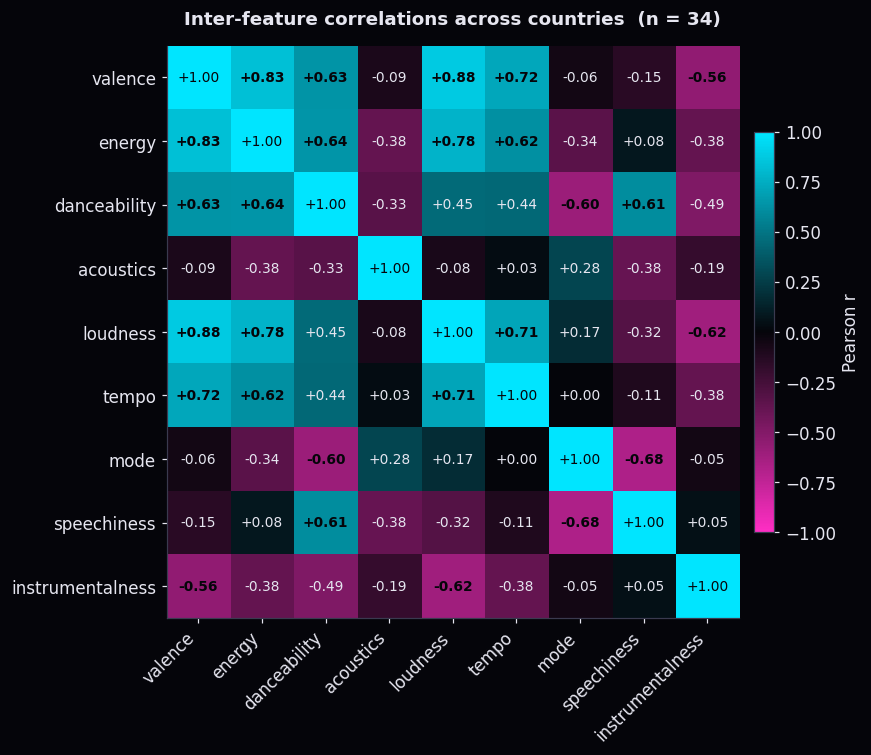

In [ ]:
X_cols = ['valence','energy','danceability','acoustics',
          'loudness','tempo','mode','speechiness']
X = cfc[X_cols].values
X_std = (X - X.mean(axis=0)) / X.std(axis=0)            
X_design = np.column_stack([np.ones(len(X_std)), X_std]) 
y = cfc['whr'].values

coefs, _, _, _ = np.linalg.lstsq(X_design, y, rcond=None)
y_pred = X_design @ coefs
R2 = 1 - ((y - y_pred)**2).sum() / ((y - y.mean())**2).sum()

print(f'R\u00b2 = {R2:.3f}    intercept = {coefs[0]:+.3f}')
for n, c in zip(X_cols, coefs[1:]):
    print(f'  beta[{n:13s}] = {c:+.3f}  (standardised)')

corr = cfc[X_cols].corr()
fig, ax = plt.subplots(figsize=(8.5, 7), dpi=110)
cmap = mpl.colors.LinearSegmentedColormap.from_list('mcg', [MAGENTA, BG, CYAN])
im = ax.imshow(corr.values, cmap=cmap, vmin=-1, vmax=1, aspect='equal')

for i in range(len(corr)):
    for j in range(len(corr)):
        v = corr.iloc[i, j]
        ax.text(j, i, f'{v:+.2f}', ha='center', va='center',
                color=BG if abs(v) > 0.55 else FG, fontsize=9,
                weight='bold' if (i != j and abs(v) > 0.5) else 'normal')

ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.index)
ax.set_title('Inter-feature correlations across countries  (n = 34)',
             pad=14, color=FG, fontsize=12)
cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Pearson r', color=FG)
plt.tight_layout()
plt.show()


**R² = 0.487 on n = 34** is a moderate fit — better than what any single feature offers (the strongest single-feature r² in §3.2 was 0.520² ≈ 0.27), worse than what we'd want for a real predictive model. The standardised coefficients confirm and *extend* the §3.2 picture; the inter-feature correlation heatmap (in the cell above) explains the multivariate's surprises:

- **Acousticness** (β = −0.420) and **speechiness** (β = +0.383) remain the two strongest predictors, confirming the marginal-correlation finding.
- **Loudness** (β = −0.275) and **energy** (β = −0.299) both pull happiness down. The heatmap shows why they look redundant: `r(loudness, energy) = +0.78`. The Spotify model derives one from the other.
- **Danceability** (β = −0.226) contributes a small negative effect; **tempo** and **mode** (both β = +0.085) contribute essentially nothing.
- **Valence is the surprise.** Marginal r = −0.163 (slightly negative); partial β = +0.481 (moderate positive). **The sign flips once we control for the other features.** The heatmap explains it: valence is strongly correlated with **loudness (+0.88)**, **energy (+0.83)** and **danceability (+0.63)** — three features that all carry *negative* coefficients in the multivariate. Valence's marginal negative tilt was inherited from this cluster. Once we hold those features constant, valence's *own* contribution to happiness emerges as positive.

**Reading the two views together.** The §3.2 bar chart shows each feature in *isolation*. The β coefficients above show each feature's contribution *after* removing the variance it shares with the other seven. The heatmap is the bridge — the picture of those shared variances. The brightest off-diagonal cells (`valence ↔ loudness +0.88`, `valence ↔ energy +0.83`, `loudness ↔ energy +0.78`) are exactly where the marginal and partial pictures diverge.

The headline doesn't change: the website reports the marginal correlation, which is what a non-scientific reader would read off the bar chart. But the multivariate adds nuance — *acousticness is doing most of the work*, and once you control for it, valence's small positive partial effect appears.


## 4 · Genre — Segel & Heer Mapping

Segel & Heer [[4](#ref4)] analysed 58 narrative visualisations from online journalism and derived a design space with two main dimensions: **Visual Narrative** (how visual elements steer attention) and **Narrative Structure** (how the story is sequenced and interactive). At its core is a spectrum: **author‑driven** on one end (the author controls pacing, order, and message), **reader‑driven** on the other (the reader explores freely). Neither end is superior, but the choice has real consequences for what a reader takes away.

We deliberately sit in the middle, using two genres from their taxonomy:

- **Magazine Style** is the main genre: our site is structured as a long‑form article split into seven numbered sections (§01 *The Question* through §07 *Your Turn*). Each section does one job: set up a claim, show the figure, interpret it and move on. The sticky nav bar (01–07) lets readers jump non‑linearly, but the default path is linear; that linearity is essential because our core finding (“The happiest countries stream some of the most emotionally subdued music”) only lands properly after the coping‑ratio formula, the global map and the correlation table. Drop the inversion in section one and it reads like a quirky claim; build to it through four sections of evidence and it reads like a conclusion. Magazine style gives us that control.
- **Martini Glass** describes the overall shape. We open wide: a broad question (“Can a playlist diagnose a nation?”), 170 614 tracks, 34 countries. Then we narrow it to the metric, the Pearson test and the genre check. Finally, in §07 we widen again and hand control to the reader: pick a country, receive its radar readout. Segel & Heer describe this arc as starting with an author‑led argument and ending with open exploration; that is exactly the shape of our site. The reader earns the interactive section by working through the argument first.

The two tables below map our concrete design choices onto the categories of Segel & Heer’s Figure 7.

### 4.1 Visual Narrative Tactics

| Category | What we used | Why it works for our story |
|----------|--------------|----------------------------|
| **Visual Structuring** | Consistent palette (cyan = Europe, magenta = Americas, amber = Asia/Oceania) across all five figures; sticky 01–07 stepper serves as a progress bar; kicker headers act as a checklist‑style progress marker. | Once a reader has absorbed the palette in the first scatter plot, they never need to relearn it. The stepper makes the narrative’s length visible, which reduces the cognitive load of a long scroll. |
| **Highlighting** | Dashed baseline at coping ratio = 1.30 in the ranking bar chart; bolded anchor‑country labels (Finland, Italy, Colombia) on the inversion scatter; the full‑bleed “⚠ THE INVERSION” callout at the exact scroll position where the paradox must register. | Every country’s deviation from the baseline is instantly visible without mental arithmetic. The callout breaks the reading flow at the right moment, forcing the reader to confront the counter‑intuitive result. |
| **Transition Guidance** | Scroll‑triggered `IntersectionObserver` fades between sections; identical axis ranges on the valence‑energy scatter (Figure 2) and the radar (Figure 5), so the eye carries position across views; the “receipt” and radar panels share the same country picker, animating both in lockstep. | The fades mimic page‑turning rather than a slideshow, preserving a reading feel. Shared ranges and linked controls maintain visual continuity even as the reader moves from a macro view (34 countries) to a micro view (one country). |

### 4.2 Narrative Structure Tactics

| Category | What we used | Why it works for our story |
|----------|--------------|----------------------------|
| **Ordering** | Fixed §01 → §07 argumentative sequence (question → metric → map → correlation → genre check → verdict → exploration). Non‑linear jumps are allowed via the sticky nav, but the default path is strictly linear. | The inversion only makes sense once the reader has the coping‑ratio definition and has seen the map split Latin America from Europe. Ordering is the main lever for author‑driven pieces, and we lean on it heavily. |
| **Interactivity** | Used sparingly and only after the argument is complete: a continent dropdown on the genre heatmap (Figure 4) to reduce visual clutter; a country picker in §07 to personalise the finding; hover tooltips on the globe and scatter to show exact values on demand. | Adding filters to every chart before the argument is finished would shift the piece toward the reader‑driven end of the spectrum prematurely. The limited interactivity in §07 feels earned. |
| **Messaging** | The core finding appears three times in different registers: (1) in the hero docket as a provocative prose statement, (2) in the verdict card as a quantitative claim (acousticness *r* = −0.52, *p* = 0.002), (3) in the inversion callout as a narrative statement (Finland, WHR #1, coping ratio 1.34). Per‑figure captions and the explainer cards in §04 reinforce the message without repeating the exact wording. | Different readers stop in different places, so message repetition across three registers maximises the chance that at least one version sticks. |


### 4.3 Why this combination worked for our story

A fully author‑driven design (a slideshow or a video) would probably lose the web audience within two minutes, while a fully reader‑driven dashboard would let users jump straight to the country picker without the context needed to interpret what they saw. The Magazine + Martini‑Glass structure holds both ends together: the first six sections belong to us, and §07 belongs to the reader. By the time someone reaches the country picker, they know what a coping ratio is, they have seen that acousticness is the strongest predictor, and they have looked at Finland’s position on two separate charts. When they then pick Finland and see its radar, they already understand why the shape looks the way it does — and that was exactly the learning path we aimed for.

## 5 · Visualizations

Small one line description per figure — what it is, and why it's the right shape for that part of the story:

#### 5.1 Notebook Visualizations

- **Figure 1 · Distribution histograms, valence + energy across all 170,614 tracks (§2.2):** establishes the global shape of the two features the original hypothesis is built on, before we aggregate to country level.
- **Figure 2 · Country-level scatter, valence × energy, coloured by continent (§2.3):** introduces the continental clustering that grounds every cultural claim that follows.
- **Figure 3 · Coping ratio bar chart per country, grouped by continent (§3.1):** ranks the metric we'll regress against happiness, with the cultural split visible at a glance.
- **Figure 4 · Pearson correlation bars, ten features vs WHR (§3.2):** the readable, signed-and-significance-coded answer to the headline question — which features actually predict happiness.
- **Figure 5 · Inversion scatter, coping ratio vs WHR with anchor labels (§3.3):** carries the project's main reveal — coping ratio runs *positively* with happiness, the opposite of the naive valence prediction.
- **Figure 6 ·Inter-feature correlation heatmap, 8 × 8 (§3.5):** visual proof of the multicollinearity that explains valence's sign-flip in the multivariate.


#### 5.2 Website Visualizations

- **V1 · Choropleth, coping ratio on an orthographic globe (§03 Map):** orthographic preserves area honestly across continents, with a diverging scale anchored at the global baseline (1.30) so deviations read in one glance.
- **V2 · Country-level scatter, valence × energy, coloured by continent (§04 Verdict):** the raw 2D audio identity per country, sets up the correlation finding by showing the space the correlation lives in.
- **V3 · Pearson correlation bars vs WHR, static SVG (§04 Verdict):**  the readable, signed-and-significance-coded answer to the headline question — which features actually predict happiness.
- **V4 · Genre log₂-ratio heatmap with continent dropdown (§05 Genre check):** the explicit cross-check against "isn't this just genre?" — the dropdown trims to one continent at a time so the cultural pattern doesn't drown in 35 rows.
- **V5 · Country audio-fingerprint radar, parent-controlled (§07 Your Turn):** Axes overlaying one selected country against the global baseline, so shape — not raw magnitude — is the comparable thing.

## 6 · Discussion

### 6.1 Why one WHR year for four years of streaming data?

Our streaming data spans 2017–2020 but we anchor every analysis to **WHR 2019**. Three reasons:

**Stability.** Within-country year-on-year WHR shifts are small relative to the *between-country* variance that dominates our test (≈ 2.6 points from Indonesia at 5.192 to Finland at 7.769 — directly visible in the `WHR_2019` dictionary in §3). With n = 34, the cross-country signal drives every correlation and is essentially insensitive to which single year we anchor on.

**Pre-shock anchor.** 2019 is the last full pre-COVID measurement. The March-2020 disruption broke a decade of survey trends in unpredictable, country-specific ways; anchoring to 2019 prevents that one-off shock from contaminating the cultural baseline we're trying to read in the music. (Our streaming data ends 2020 anyway, so the post-shock period is small.)

**Listening accumulates across years and we can't slice it cleanly.** A track that hits the chart in December 2018 keeps accumulating plays through 2019 and 2020. Our data records *daily chart appearances*, not *cumulative listening time per year* — so any per-year split would have to assume how attention decays after a track leaves the chart, and we have no ground truth for that. Anchoring to one WHR year sidesteps a per-year listening attribution we can't construct.

A multi-year WHR robustness check is flagged as future work in §6.3 — this notebook loads only WHR 2019, so we can't run it without acquiring additional data.

### 6.2 What went well

- **The narrative shifted under the data.** The original hypothesis — high-valence countries should be happy countries — failed in a sharp, interpretable way (the inversion in §3.3). Owning that pivot made the piece stronger than a forced confirmation would have been.
- **The coping ratio is interpretable end-to-end.** A single dimensionless number with `1.0` as a natural anchor; every reader can read deviations from 1 immediately.
- **The §3.5 multivariate revealed a genuine suppression effect.** Valence's coefficient flipping from r = −0.163 (marginal) to β = +0.481 (partial) was only visible in the full multivariate; the §3.5 inter-feature heatmap traces the cause to valence's strong correlations with loudness (+0.88), energy (+0.83), and danceability (+0.63) — three features that all carry negative coefficients.

### 6.3 What's still missing — and could be improved

- **Small n limits statistical power.** With 34 countries, only acousticness and speechiness clear conventional `p < 0.05`. The other seven features may carry real but smaller effects we are underpowered to detect.
- **Spotify is a black box.** The valence/energy extractor is closed-source; we can't audit how it computes scores. An open-source reproduction would test whether the cross-cultural gap is a measurement artefact rather than a cultural one.
- **Causality unaddressed.** All cross-sectional. GDP, urbanisation, streaming penetration, English-language exposure, age structure — plausible third-variable drivers we cannot disentangle. The project is descriptive; we never claim causality.
- **Survivorship bias and OECD skew.** Top-200 captures the *most popular* music, not what a random citizen hears. The 34-country sample skews wealthy and large — Sub-Saharan Africa is entirely absent; South Asia is minimally represented. Generalising the headline beyond the OECD-plus sample would be a stretch.

### 6.4 Summary

Valence didn't predict happiness on the marginal. Acousticness did — strongly negative (r = −0.520, p = 0.0016). Speechiness did — strongly positive (r = +0.467, p = 0.0053). The coping ratio runs the *opposite* way to the naive reading: happier countries cope louder, on average. The multivariate confirms acousticness and speechiness as the dominant signals, and reveals that valence's marginal flatness was hiding a small positive partial effect — suppressed by valence's strong correlations with loudness (+0.88), energy (+0.83), and danceability (+0.63), all features carrying negative coefficients. Finland, the world's happiest country, sits among the top five by coping ratio. Spotify hears something the survey hears too — but it isn't what valence promised.


## 7 · Contributions

*All members reviewed every section and signed off on the final piece.*

| Area | Lead |
|---|---|
| Dataset sourcing, cleaning, country/continent mapping | **Rupak Parmeshwar Kadhare** |
| Coping-ratio definition, §3.1 metric design, §3.2 correlations | **Rupak Parmeshwar Kadhare, Sandesh Oli** |
| §3.3 inversion analysis, §3.4 genre conditional probabilities | **Rupak Parmeshwar Kadhare, Sandesh Oli** |
| §3.5 multivariate OLS, §6.1 anchor-year justification | **Sandesh Oli** |
| Website design (CSS, layout, palette, type system) | **Matias Fernando Yuan** |
| Plotly + matplotlib figures, V1–V5 implementation | **Rupak Parmeshwar Kadhare** |
| Narrative copy on the site, Segel–Heer §4 mapping, §6 discussion | **Sandesh Oli** |
| Notebook assembly, references, final QA | **Rupak Parmeshwar Kadhare, Sandesh Oli, Matias Fernando Yuan** |



## 8 · References

Following academic standards (Vancouver-style numbered citations as used in the IEEE TVCG, where Segel & Heer was published).

<a id='ref1'></a>[1] Spotify HUGE database - daily charts over 3 years. Available at: https://www.kaggle.com/datasets/pepepython/spotify-huge-database-daily-charts-over-3-years.

<a id='ref2'></a>[2] Helliwell, J. F., Layard, R., & Sachs, J. (Eds.). (2019). *World Happiness Report 2019*. Sustainable Development Solutions Network. https://worldhappiness.report/ed/2019/. Underlying survey data: Gallup World Poll, 2016–2018.

<a id='ref3'></a>[3] Saarikallio, S., & Erkkilä, J. (2007). The role of music in adolescents' mood regulation. *Psychology of Music*, 35(1), 88–109. https://doi.org/10.1177/0305735607068889

<a id='ref4'></a>[4] Segel, E., & Heer, J. (2010). Narrative visualization: Telling stories with data. *IEEE Transactions on Visualization and Computer Graphics*, 16(6), 1139–1148. https://doi.org/10.1109/TVCG.2010.179
